<a href="https://colab.research.google.com/github/GabrielMtzSoltero/MIEC/blob/main/MIEC_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error




In [12]:
df = sns.load_dataset('penguins')

print("=== VISTA PREVIA DEL DATASET ===")
print(df.head(), "\n")
df = df.dropna(subset=['flipper_length_mm', 'body_mass_g'])
# Usaremos 'MedInc' (Ingreso medio de los residentes) como variable predictora principales
# La variable objetivo 'MedHouseVal' viene expresada en cientos de miles de dólares ($100k)
X = df[['flipper_length_mm']]
y = df['body_mass_g']

=== VISTA PREVIA DEL DATASET ===
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female   



In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

# Extracción de parámetros
intercepto = model.intercept_
pendiente = model.coef_[0]

print("=== PARÁMETROS DEL MODELO ===")
print(f"Pendiente (β₁):    {pendiente:.4f}")
print(f"Intercepto (β₀):   {intercepto:.4f}")
print(f"Ecuación:          y = {intercepto:.2f} + {pendiente:.2f}*x\n")


=== PARÁMETROS DEL MODELO ===
Pendiente (β₁):    48.8297
Intercepto (β₀):   -5614.0671
Ecuación:          y = -5614.07 + 48.83*x



In [15]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN (TEST) ===")
print(f"Error Absoluto Medio (MAE):         {mae:.4f}")
print(f"Error Cuadrático Medio (MSE):       {mse:.4f}")
print(f"Raíz del MSE (RMSE):               {rmse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}\n")




=== MÉTRICAS DE EVALUACIÓN (TEST) ===
Error Absoluto Medio (MAE):         315.8597
Error Cuadrático Medio (MSE):       144928.5933
Raíz del MSE (RMSE):               380.6949
Coeficiente de Determinación (R²): 0.7820



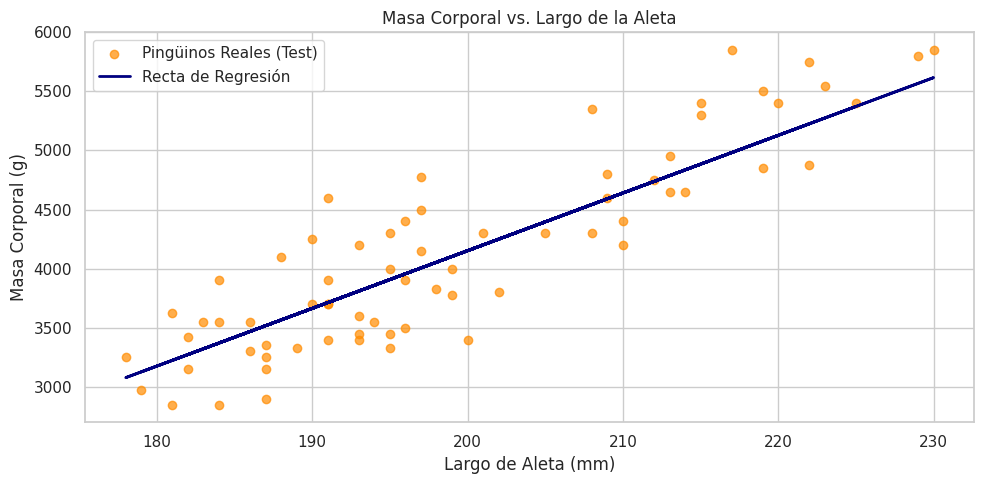

In [21]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
fig=plt.figure()
# Gráfica 1: Recta de Ajuste sobre Datos Reales
plt.scatter(X_test, y_test, color='darkorange', alpha=0.7, label='Pingüinos Reales (Test)')
plt.plot(X_test, y_pred, color='navy', linewidth=2, label='Recta de Regresión')
plt.title('Masa Corporal vs. Largo de la Aleta')
plt.xlabel('Largo de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.legend()


plt.tight_layout()
plt.show()